<a href="https://colab.research.google.com/github/SutamaSarkar/RealiabilitySimulation/blob/main/5_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

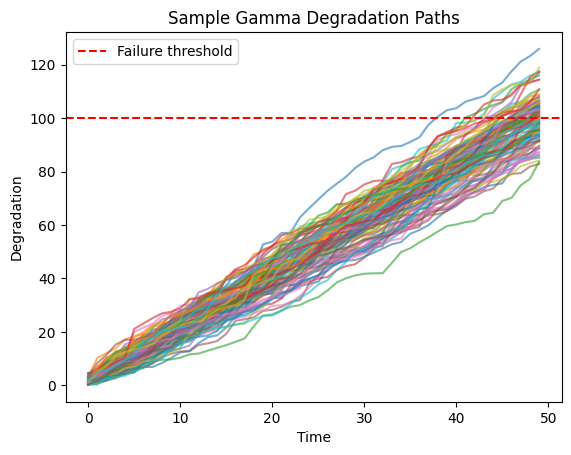

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (example values)
alpha = 2
beta = 1
Dc = 100

T = 50
n_sim = 100

paths = np.zeros((n_sim, T))

for i in range(n_sim):
    D = 0
    for t in range(T):
        dD = np.random.gamma(shape=alpha, scale=beta)
        D += dD
        paths[i, t] = D

# Plot some paths
for i in range(100):
    plt.plot(paths[i], alpha=0.6)

plt.axhline(Dc, color='red', linestyle='--', label='Failure threshold')
plt.xlabel('Time')
plt.ylabel('Degradation')
plt.legend()
plt.title('Sample Gamma Degradation Paths')
plt.show()

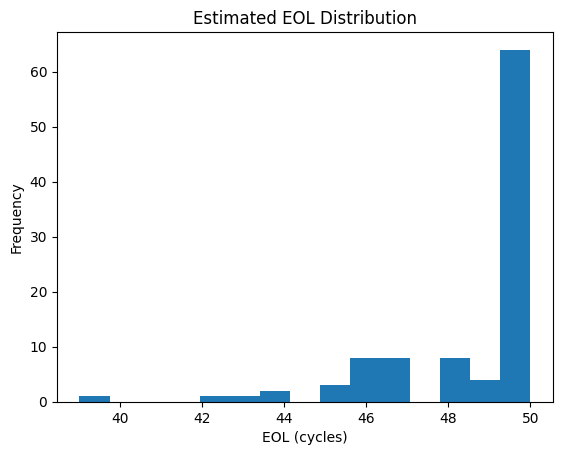

In [2]:
EOL = []

for i in range(n_sim):
    failure_time = None
    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1
            break
    if failure_time is None:
        failure_time = T  # censored
    EOL.append(failure_time)

# Histogram
plt.hist(EOL, bins=15)
plt.xlabel('EOL (cycles)')
plt.ylabel('Frequency')
plt.title('Estimated EOL Distribution')
plt.show()

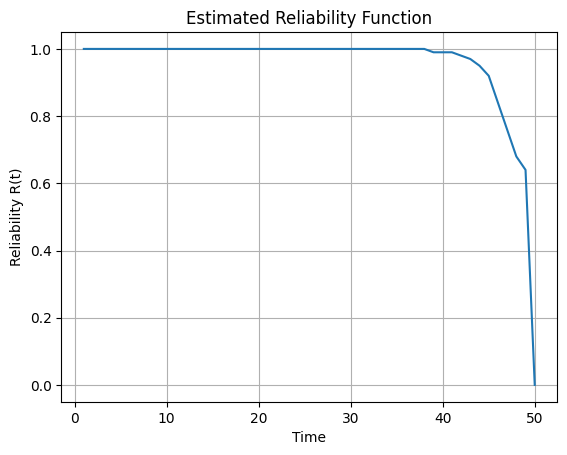

In [3]:
R = []

for t in range(1, T+1):
    survivors = sum(1 for e in EOL if e > t)
    R.append(survivors / n_sim)

plt.plot(range(1, T+1), R)
plt.xlabel('Time')
plt.ylabel('Reliability R(t)')
plt.title('Estimated Reliability Function')
plt.grid()
plt.show()

In [4]:
EOL = []
censored = []   # 0 = failure observed, 1 = censored

for i in range(n_sim):
    failure_time = None

    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1
            break

    if failure_time is None:
        EOL.append(T)
        censored.append(1)   # censored
    else:
        EOL.append(failure_time)
        censored.append(0)   # actual failure

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Parameters
alpha = 2
beta = 1
Dc = 100
T = 50
n_sim = 100

# Simulate degradation paths
paths = np.zeros((n_sim, T))

for i in range(n_sim):
    D = 0
    for t in range(T):
        dD = np.random.gamma(shape=alpha, scale=beta)
        D += dD
        paths[i, t] = D

# ---- EOL with censoring ----
EOL = []
censored = []   # 0 = failure, 1 = censored

for i in range(n_sim):
    failure_time = None

    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1
            break

    if failure_time is None:
        EOL.append(T)
        censored.append(1)   # censored
    else:
        EOL.append(failure_time)
        censored.append(0)   # failure

# ---- Kaplan-Meier reliability ----
kmf = KaplanMeierFitter()
kmf.fit(EOL, event_observed=[1-c for c in censored])

# ---- Plot ----
plt.figure()
kmf.plot()
plt.xlabel("Time (cycles)")
plt.ylabel("Reliability R(t)")
plt.title("Reliability Function with Censoring (Kaplan-Meier)")
plt.grid()
plt.show()

ModuleNotFoundError: No module named 'lifelines'

In [ ]:
!pip install lifelines

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Parameters
alpha = 2
beta = 1
Dc = 100
T = 50
n_sim = 100

# Simulate degradation paths
paths = np.zeros((n_sim, T))

for i in range(n_sim):
    D = 0
    for t in range(T):
        dD = np.random.gamma(shape=alpha, scale=beta)
        D += dD
        paths[i, t] = D

# ---- EOL with censoring ----
EOL = []
censored = []   # 0 = failure, 1 = censored

for i in range(n_sim):
    failure_time = None

    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1
            break

    if failure_time is None:
        EOL.append(T)
        censored.append(1)   # censored
    else:
        EOL.append(failure_time)
        censored.append(0)   # failure

# ---- Kaplan-Meier reliability ----
kmf = KaplanMeierFitter()
kmf.fit(EOL, event_observed=[1-c for c in censored])

# ---- Plot ----
plt.figure()
kmf.plot()
plt.xlabel("Time (cycles)")
plt.ylabel("Reliability R(t)")
plt.title("Reliability Function with Censoring (Kaplan-Meier)")
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
alpha = 2
beta = 1
Dc = 100
T = 50
n_sim = 100

# Repair rate (maintainability parameter)
lambda_repair = 0.2   # higher = faster repair

# Simulate degradation
paths = np.zeros((n_sim, T))

for i in range(n_sim):
    D = 0
    for t in range(T):
        dD = np.random.gamma(shape=alpha, scale=beta)
        D += dD
        paths[i, t] = D

# ---- EOL + censoring ----
EOL = []
censored = []

for i in range(n_sim):
    failure_time = None

    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1
            break

    if failure_time is None:
        EOL.append(T)
        censored.append(1)
    else:
        EOL.append(failure_time)
        censored.append(0)

# ---- Maintainability (Repair Times) ----
repair_times = []

for i in range(n_sim):
    if censored[i] == 0:   # only for failed systems
        Tr = np.random.exponential(scale=1/lambda_repair)
        repair_times.append(Tr)

# ---- Maintainability Function ----
t_vals = np.linspace(0, 20, 50)
M = []

for t in t_vals:
    repaired = sum(1 for tr in repair_times if tr <= t)
    M.append(repaired / len(repair_times))

# ---- Plot Maintainability ----
plt.figure()
plt.plot(t_vals, M)
plt.xlabel("Repair Time")
plt.ylabel("Maintainability M(t)")
plt.title("Maintainability Function")
plt.grid()
plt.show()

In [ ]:
# ---- Maintainability (Repair Modeling) ----

lambda_repair = 0.2   # repair rate (adjust as needed)

repair_times = []     # store system repair times

for i in range(n_sim):

    if censored[i] == 0:   # only failed systems

        # Example: assume system has 3 components (like your t1, t2, t3 idea)
        n_components = 3

        component_repairs = []

        for j in range(n_components):
            Tr_i = np.random.exponential(scale=1/lambda_repair)
            component_repairs.append(Tr_i)

        # Total system repair time (sum of components)
        Tr_total = sum(component_repairs)

        repair_times.append(Tr_total)

# ---- Maintainability Function ----
t_vals = np.linspace(0, 20, 50)
M = []

for t in t_vals:
    repaired = sum(1 for tr in repair_times if tr <= t)
    M.append(repaired / len(repair_times))

# ---- Plot Maintainability ----
plt.figure()
plt.plot(t_vals, M)
plt.xlabel("Repair Time")
plt.ylabel("Maintainability M(t)")
plt.title("Maintainability Function")
plt.grid()
plt.show()

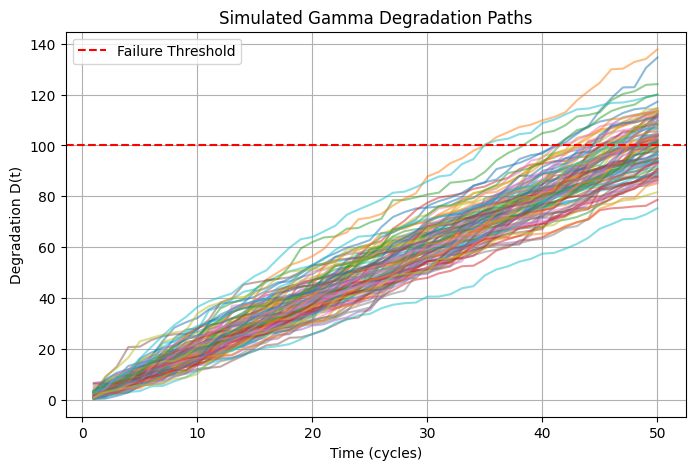

In [6]:
#5a
import numpy as np
import matplotlib.pyplot as plt

# Parameters
alpha = 2       # shape rate
beta = 1        # scale
Dc = 100        # failure threshold
T = 50          # total time steps
dt = 1          # time step
n_sim = 100     # number of simulations

# Store degradation paths
paths = np.zeros((n_sim, T))

# Simulation
for i in range(n_sim):
    D = 0
    for t in range(T):
        # Gamma increment: shape = alpha * dt, scale = beta
        dD = np.random.gamma(shape=alpha * dt, scale=beta)
        D += dD
        paths[i, t] = D

# Plot degradation paths
plt.figure(figsize=(8, 5))
for i in range(n_sim):
    plt.plot(range(1, T+1), paths[i], alpha=0.5)

# Failure threshold
plt.axhline(y=Dc, color='red', linestyle='--', label='Failure Threshold')

plt.xlabel('Time (cycles)')
plt.ylabel('Degradation D(t)')
plt.title('Simulated Gamma Degradation Paths')
plt.legend()
plt.grid()
plt.show()

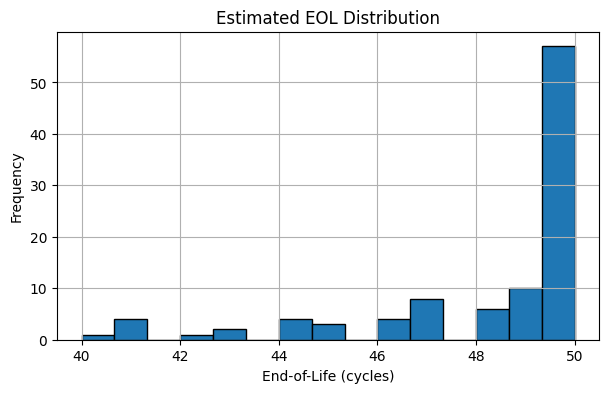

In [7]:
#5b
import numpy as np
import matplotlib.pyplot as plt

# Parameters (same as part a)
alpha = 2
beta = 1
Dc = 100
T = 50
dt = 1
n_sim = 100

# ---- Simulate degradation paths ----
paths = np.zeros((n_sim, T))

for i in range(n_sim):
    D = 0
    for t in range(T):
        dD = np.random.gamma(shape=alpha * dt, scale=beta)
        D += dD
        paths[i, t] = D

# ---- Compute EOL ----
EOL = []
censored = []   # 0 = failure observed, 1 = censored

for i in range(n_sim):
    failure_time = None

    for t in range(T):
        if paths[i, t] >= Dc:
            failure_time = t + 1   # time index starts from 1
            break

    if failure_time is None:
        EOL.append(T)
        censored.append(1)   # censored
    else:
        EOL.append(failure_time)
        censored.append(0)   # failure observed

# ---- Plot EOL distribution ----
plt.figure(figsize=(7, 4))
plt.hist(EOL, bins=15, edgecolor='black')
plt.xlabel('End-of-Life (cycles)')
plt.ylabel('Frequency')
plt.title('Estimated EOL Distribution')
plt.grid()
plt.show()

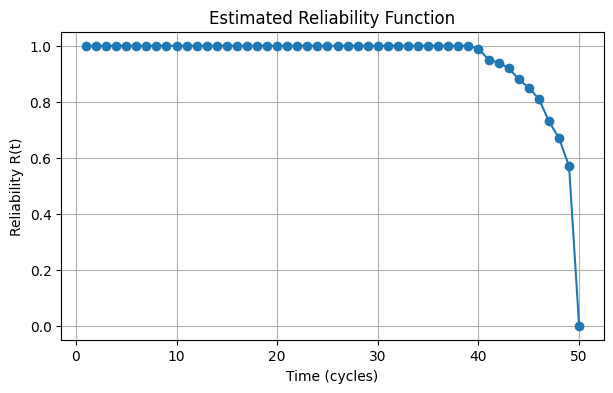

In [8]:
#5c
import numpy as np
import matplotlib.pyplot as plt

# Assume EOL already computed from part (b)

T = 50
n_sim = len(EOL)

# Compute reliability
R = []

for t in range(1, T + 1):
    survivors = sum(1 for e in EOL if e > t)
    R.append(survivors / n_sim)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, T + 1), R, marker='o')
plt.xlabel('Time (cycles)')
plt.ylabel('Reliability R(t)')
plt.title('Estimated Reliability Function')
plt.grid()
plt.show()

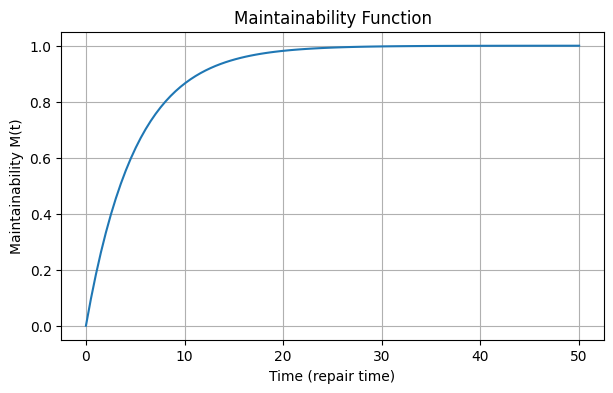

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Repair rate (example)
mu = 0.2   # repairs per cycle (MTTR = 5)

# Time range
t = np.linspace(0, 50, 100)

# Maintainability function
M = 1 - np.exp(-mu * t)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(t, M)
plt.xlabel('Time (repair time)')
plt.ylabel('Maintainability M(t)')
plt.title('Maintainability Function')
plt.grid()
plt.show()